# Corporación Favorita Grocery Sales Forecasting
## Feature Engineering + Machine Learning Models

## Introduction

**Objective**

This notebook evaluates machine learning forecasting models using a feature engineering approach.

The original daily time series is transformed into a supervised learning dataset by creating:
- lag features (past sales)
- rolling statistics (smoothed demand signals)
- calendar features (weekday/weekend + holiday indicators from Notebook 01)

**Train/Test split**
- **Training:** 2013-01-02 -> 2013-12-31  
- **Test:** 2014-01-01 -> 2014-03-31  

Models are evaluated on the fixed test period using:
- **MAE** (primary)
- **RMSE**
- **sMAPE**

The goal is to compare ML models against the statistical benchmark selected in Notebook 02.

This section installs required libraries when running the notebook in Google Colab.
For GitHub publication and local execution, dependencies are listed in `requirements.txt`.

**Computational Note**: The LSTM model is computationally intensive and may be slow to train on hardware without GPU support. All other models run efficiently on standard hardware.

## 2. Data Loading

In [42]:
# Load Libraries

# Data Handling
# ----------------------------------------------------------
import pandas as pd
import numpy as np

# Visualization
# ----------------------------------------------------------
import matplotlib.pyplot as plt

# Machine Learning Models
# ----------------------------------------------------------
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Deep Learning (LSTM)
# ----------------------------------------------------------
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Hybrid/Statistical model
# ----------------------------------------------------------
from prophet import Prophet

# Preprocessing and Model Selection
# ----------------------------------------------------------
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit


# Evaluation Metrics
# ----------------------------------------------------------
from sklearn.metrics import mean_absolute_error, mean_squared_error, make_scorer

# Experiment Tracking (MLflow)
# ----------------------------------------------------------
import mlflow
import mlflow.pyfunc
from mlflow.tracking import MlflowClient

# Hyperparameter Optimization/Tuning 
# ----------------------------------------------------------
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
from sklearn.model_selection import GridSearchCV

import joblib

In [82]:
from pathlib import Path

# Notebook is in notebooks
BASE_DIR = Path().resolve().parent
DATA_PATH  = BASE_DIR / "data"
MODEL_PATH = BASE_DIR / "model/" 

In [44]:
# MLflow setup
MLFLOW_PATH = BASE_DIR / "mlflow.db"

# Tracking URI points to the folder where MLflow stores runs
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_PATH}")

# Experiment groups runs for this project
mlflow.set_experiment("Favorita_Sales_Forecasting")

<Experiment: artifact_location='/Users/mapi/Desktop/Masterschool_Data_Science/TimeSeries/corporacion_favorita/notebooks/mlruns/1', creation_time=1772376865376, experiment_id='1', last_update_time=1772376865376, lifecycle_stage='active', name='Favorita_Sales_Forecasting', tags={}, workspace='default'>

In [45]:
# Load the dataset
df = pd.read_csv(DATA_PATH / "timeseries_cleaned.csv")

print("Dataset loaded.")
# Quick check
df.head()

Dataset loaded.


,date,unit_sales,day_of_week,is_weekend,holiday_weekday,holiday_weekend,is_national,is_regional,is_local
0,2013-01-02,582.0,2,0,0,0,0,0,0
1,2013-01-03,310.0,3,0,0,0,0,0,0
2,2013-01-04,338.0,4,0,0,0,0,0,0
3,2013-01-05,654.0,5,1,0,1,1,0,0
4,2013-01-06,979.0,6,1,0,0,0,0,0


In [46]:
# Dataframe structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 454 entries, 0 to 453
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             454 non-null    object 
 1   unit_sales       454 non-null    float64
 2   day_of_week      454 non-null    int64  
 3   is_weekend       454 non-null    int64  
 4   holiday_weekday  454 non-null    int64  
 5   holiday_weekend  454 non-null    int64  
 6   is_national      454 non-null    int64  
 7   is_regional      454 non-null    int64  
 8   is_local         454 non-null    int64  
dtypes: float64(1), int64(7), object(1)
memory usage: 32.0+ KB


In [47]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])

# Set date as index
df = df.set_index("date").sort_index()

# Force daily frequency to help statsmodels
df = df.asfreq("D")

# quick checks
print("Index frequency:", df.index.freq)

Index frequency: <Day>


## 3. Feature Engineering

#### Feature Engineering

In [48]:
# All lag and rolling features use only past information.
# No future data is used in feature construction.
df_ml = df.copy()

# Lag features past sales
for l in [1, 2, 3, 7, 14]:
    df_ml[f"lag_{l}"] = df_ml["unit_sales"].shift(l)

# Rolling statistics past only
df_ml["roll_mean_7"]  = df_ml["unit_sales"].shift(1).rolling(7).mean()
df_ml["roll_mean_14"] = df_ml["unit_sales"].shift(1).rolling(14).mean()
df_ml["roll_mean_28"] = df_ml["unit_sales"].shift(1).rolling(28).mean()
df_ml["roll_std_7"]   = df_ml["unit_sales"].shift(1).rolling(7).std()


# Cyclical encoding for weekly seasonality
# Preserves circular structure of days (Mon close to Sun)
df_ml["dow_sin"] = np.sin(2 * np.pi * df_ml["day_of_week"] / 7)
df_ml["dow_cos"] = np.cos(2 * np.pi * df_ml["day_of_week"] / 7)

# Drop initial rows where lag/rolling features are undefined (NaN)
# This avoids leakage and ensures a clean supervised-learning dataset
df_ml = df_ml.dropna()


**Note**: All lag/rolling features are built using only past information (`shift` and non-centered rolling windows), preventing leakage.

## 4. Train/Test Split

In [49]:
# Time-based split, same dates as statistical models
train_ml = df_ml.loc["2013-01-02":"2013-12-31"].copy()
test_ml  = df_ml.loc["2014-01-01":"2014-03-31"].copy()

y_train_ml = train_ml["unit_sales"]
y_test_ml  = test_ml["unit_sales"]

features = [
    # lags
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14",
    # rolling
    "roll_mean_7", "roll_mean_14", "roll_mean_28", "roll_std_7",
    # calendar / seasonality
    "dow_sin", "dow_cos",
    "holiday_weekday", "holiday_weekend"
]

# Include holiday categories
features += ["is_national", "is_regional", "is_local"]

X_train_ml = train_ml[features]
X_test_ml  = test_ml[features]


## 5. Helpers

This section defines utility functions used consistently across all models:

- A standardized evaluation function (MAE, RMSE, sMAPE)
- Two plotting functions for visual comparison of forecasts vs. actual values
- A results container to store model performance in a structured format
- A function to log forecast plots

In [50]:
# Helper function for evaluation
def evaluate_model(y_true, y_pred, model_name, family="ML"):

  """
  - MAE is used as the primary metric
  - RMSE highlights large errors (spikes/outliers)
  - sMAPE provides a stable percentage error metric (works with zeros)

  Compute forecast evaluation metrics and return a dictionary
  that can be appended to a results table.

  Note:
  - The index is aligned to avoid accidental misalignment between y_true and y_pred.
  - R² is not included because it is less informative for time series forecasting
  and can be misleading under strong seasonality.
  """

  # Ensure correct temporal alignment before computing metrics
  y_true, y_pred = y_true.align(y_pred, join="inner")

  # Core metrics
  mae = mean_absolute_error(y_true, y_pred)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))

  # Stable percentage metric handles zeros safely
  smape = 100 * np.mean(
      2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)
  )

  # Print summary
  print(f"\n{model_name}")
  print(f"MAE   : {mae:.2f}")
  print(f"RMSE  : {rmse:.2f}")
  print(f"sMAPE : {smape:.2f}%")

  return {
      "Model": model_name,
      "MAE": round(mae,2),
      "RMSE": round(rmse,2),
      "sMAPE (%)": round(smape,2),
      "Family": family
  }


**Note**:
- **MAE** measures the average absolute error in the original sales units (primary metric).
- **RMSE** penalizes large errors more strongly and is useful when spikes matter.
- **sMAPE** provides a percentage-based error measure and remains stable when actual values are near zero.

In [51]:
# Helper function for visualization
def plot_full_view(y_train, y_test, y_forecast, title):
  """
    Plot training data, test actuals, and the forecast on the same axis.
    This provides a full temporal view and highlights the train/test split.
  """
  plt.figure(figsize=(14,5))

  plt.plot(y_train.index, y_train, label="Train", linewidth=1)
  plt.plot(y_test.index, y_test, label="Test Actual", linewidth=1)
  plt.plot(y_forecast.index, y_forecast, label="Forecast", linestyle="--", linewidth=1.5)

  # Mark the boundary between train and test
  plt.axvline(y_train.index[-1], color="black", linestyle=":", linewidth=1, label="Train/Test Split")

  plt.title(title)
  plt.xlabel("Date")
  plt.ylabel("Unit Sales")
  plt.legend()
  plt.tight_layout()
  plt.show()

In [52]:
# Plot only Test
def plot_test_view(y_test, y_pred, title):
    plt.figure(figsize=(12,4))
    plt.plot(y_test.index, y_test, label="Actual", linewidth=1)
    plt.plot(y_pred.index, y_pred, label="Forecast", linewidth=1.5)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Unit Sales")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [53]:
# Quick in-notebook comparison table (MLflow is used for persistent tracking)
results = []

**Note**:
- `results` is a quick notebook summary for exploratory comparison
- MLflow is used to persist and compare shortlisted candidate models across notebooks

In [54]:
# MLflow Artifact Helper: log forecast plot
# Logs actual vs forecast comparison as artifact
def log_forecast_plot(y_test, y_pred, model_name):
    """
    Logs a forecast vs actual plot as an MLflow artifact.

    Parameters
    ----------
    y_test : pd.Series  --> Actual test values
    y_pred : pd.Series  --> Model forecast aligned with test index
    model_name : str --> Used for plot title and artifact filename
    """

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(y_test.index, y_test.values, label="Actual", linewidth=1.5)
    ax.plot(y_pred.index, y_pred.values, label="Forecast", linewidth=1.5)

    ax.set_title(f"{model_name} — Forecast vs Actual (Test)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Unit Sales")
    ax.legend()

    plt.tight_layout()

    # Safe artifact name (no spaces)
    artifact_name = model_name.lower().replace(" ", "_")
    mlflow.log_figure(fig, f"plots/{artifact_name}_forecast.png")

    plt.close(fig)
    print(f"Logged artifact: plots/{artifact_name}_forecast.png")


## 6. Models

### 6.1 Machine Learning Models

#### Linear Regression


Linear Regression
MAE   : 102.58
RMSE  : 151.33
sMAPE : 21.36%


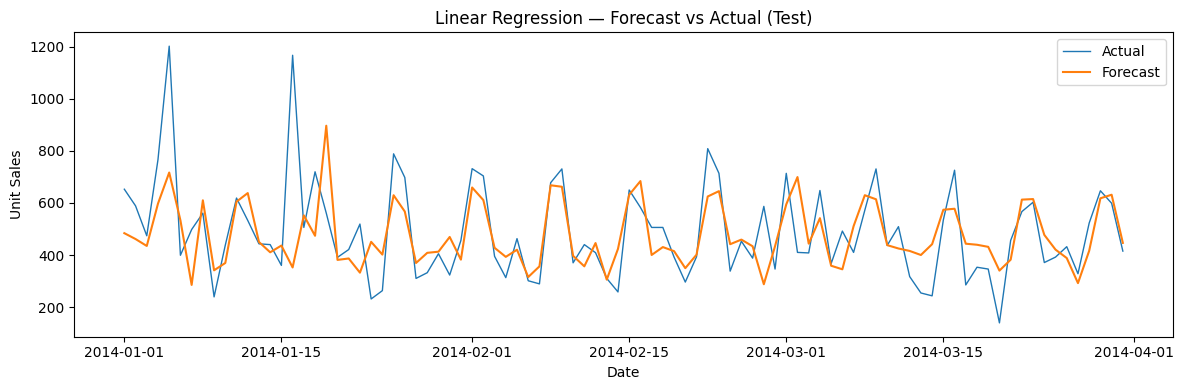

In [55]:
# Linear Regression
# Simple linear model
lr = LinearRegression()
lr.fit(X_train_ml, y_train_ml)

lr_forecast = lr.predict(X_test_ml)
lr_forecast = pd.Series(lr_forecast, index=y_test_ml.index)

# Call the evaluation function
lr_metrics = evaluate_model(y_test_ml, lr_forecast, "Linear Regression", family = "ML")

# Store the result
results.append(lr_metrics)

plot_test_view(y_test_ml, lr_forecast, "Linear Regression — Forecast vs Actual (Test)")

**Note**:  
Linear Regression provides a strong first machine-learning baseline (MAE = **102.58**, sMAPE = **21.36%**), indicating that the engineered features (lags, rolling statistics, and weekly seasonality encoding) already carry meaningful predictive information.

The forecast tends to be smoother than the observed series, which is expected for a linear model trained on aggregated daily sales.  
This model is retained as a simple, interpretable benchmark before testing more flexible nonlinear approaches.

#### Random Forest


Random Forest
MAE   : 97.42
RMSE  : 140.80
sMAPE : 20.33%


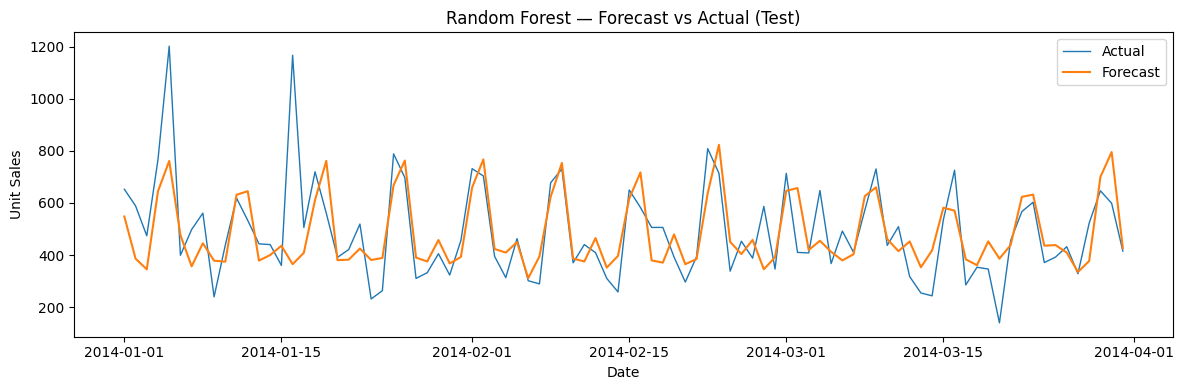

In [56]:
# Random Forest
# Nonlinear ensemble model.
# Captures interactions and nonlinearities in lag and rolling features
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=3,
    n_jobs=-1
)
rf.fit(X_train_ml, y_train_ml)

rf_forecast = rf.predict(X_test_ml)
rf_forecast = pd.Series(rf_forecast, index=y_test_ml.index)

# Call the evaluation function
rf_metrics = evaluate_model(y_test_ml, rf_forecast, "Random Forest", family="ML")

# Store the result
results.append(rf_metrics)

plot_test_view(y_test_ml, rf_forecast, "Random Forest — Forecast vs Actual (Test)")

**Note**:  
Random Forest improves forecast accuracy (MAE = **97.42**, sMAPE = **20.33%**) by capturing nonlinear interactions between lagged demand signals and weekly seasonality.

Predictions typically follow the weekly structure more closely than the linear baseline, while extreme spikes remain challenging and may still be partially smoothed.

#### Random Forest Hyperparameter Grid Tuning

Best params: {'max_depth': 2, 'min_samples_leaf': 1, 'n_estimators': 50}

Random Forest (tuned)
MAE   : 96.70
RMSE  : 141.77
sMAPE : 20.15%


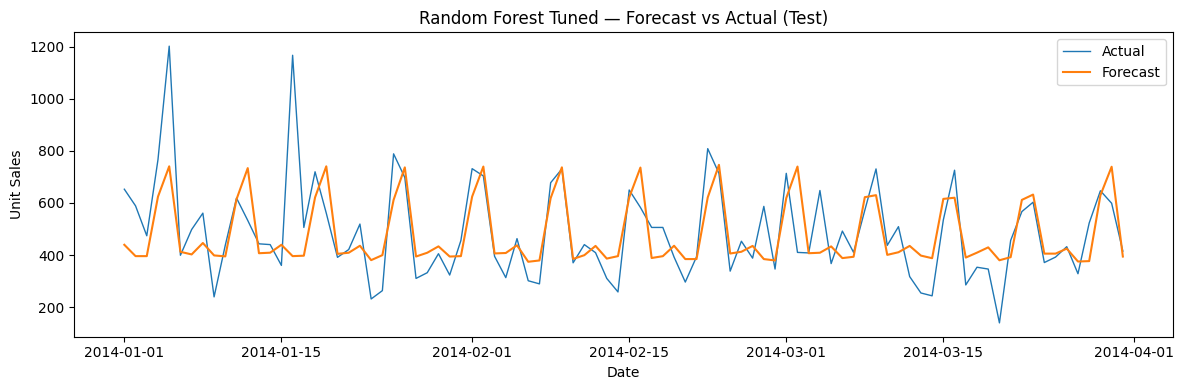

In [57]:
# Hyperparameter grid for Random Forest tuning
param_grid = {
    "n_estimators": [50, 100, 150, 200], # number of trees in the forest
    "max_depth": [2, 3, 5, None], # maximum depth of each tree (None = unlimited)
    "min_samples_leaf": [1, 5] # minimum samples required at each leaf node
}

# Base estimator with fixed random state for reproducibility
rf_base = RandomForestRegressor(random_state=3, n_jobs=-1)
 
grid_search = GridSearchCV(
    rf_base,
    param_grid,
    cv=3,       # 3-fold cross-validation on training data only
    scoring="neg_mean_absolute_error", 
)

# Fit grid search on training data only
grid_search.fit(X_train_ml, y_train_ml)

# Extract best estimator based on cross-validated MAE
best_rf = grid_search.best_estimator_
print("Best params:", grid_search.best_params_)

# Generate forecast on test set using best estimator
rf_tuned_forecast = pd.Series(
    best_rf.predict(X_test_ml),
    index=y_test_ml.index
)

# Evaluate and store results
rf_tuned_metrics = evaluate_model(
    y_true=y_test_ml,
    y_pred=rf_tuned_forecast,
    model_name="Random Forest (tuned)",
    family="ML"
)
results.append(rf_tuned_metrics)

plot_test_view(y_test_ml, rf_tuned_forecast, "Random Forest Tuned — Forecast vs Actual (Test)")

**Note**: Grid search identifies `max_depth=2` and `n_estimators=50` as the optimal configuration, a relatively shallow and compact forest.

This result is consistent with the limited training horizon (one year of data): simpler models tend to generalize better by avoiding overfitting to patterns specific to the training period.

Random Forest (tuned) achieves MAE: 96.70, RMSE: 141.77, sMAPE: 20.15%, a modest but consistent improvement over the baseline configuration.

#### XGBoost


XGBoost (lags + cyclical)
MAE   : 95.52
RMSE  : 140.94
sMAPE : 20.04%


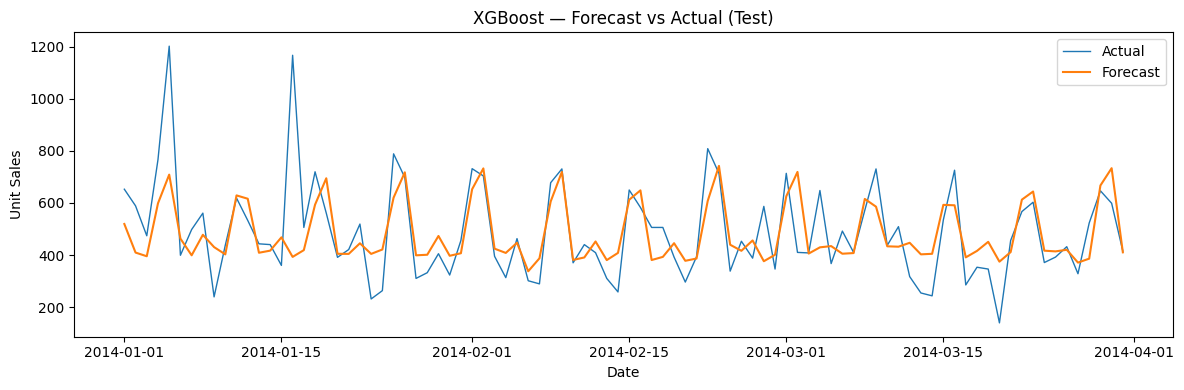

In [58]:
# XGBoost Regressor
# Gradient boosting trees are often strong for tabular time series features (lags/rolling/calendar)
xgb_model = XGBRegressor(
    n_estimators=250,
    learning_rate=0.01,
    colsample_bytree=0.8,
    max_depth=3,
    random_state=3,
    min_child_weight=2,
    n_jobs = -1
)

xgb_model.fit(X_train_ml, y_train_ml)

# Forecast
xgb_forecast = xgb_model.predict(X_test_ml)
xgb_forecast = pd.Series(xgb_forecast, index=y_test_ml.index)

# Evaluation
xgboost_metrics = evaluate_model(y_test_ml, xgb_forecast, "XGBoost (lags + cyclical)", family="ML")
# Store results
results.append(xgboost_metrics)

plot_test_view(y_test_ml, xgb_forecast, "XGBoost — Forecast vs Actual (Test)")

**Note**:  
XGBoost achieves the best performance among the tested ML models (MAE = **95.52**, sMAPE = **20.03%**).

The model combines autoregressive information (lags / rolling features) with a strong weekly seasonal signal, producing forecasts that align well with the dominant structure of the series.  
Holiday-related indicators appear to contribute only marginally in this simplified aggregated setting.

#### XGBoost HyperOpt Tuning

In [59]:
# HyperOpt tuning (TimeSeries CV)

# Tune XGBoost using TimeSeriesSplit to avoid leakage.
tscv = TimeSeriesSplit(n_splits=5)

In [60]:
# Search space is kept realistic to reduce overfitting risk.
search_space = {
    "max_depth": hp.choice("max_depth", [2, 3, 4, 5]),
    "learning_rate": hp.uniform("learning_rate", 0.01, 0.2),
    "n_estimators": hp.choice("n_estimators", [50, 100, 200, 250, 300]),
    "min_child_weight": hp.choice("min_child_weight", [1, 2, 3, 5]),
    "subsample": hp.uniform("subsample", 0.6, 1.0),
    "colsample_bytree": hp.uniform("colsample_bytree", 0.6, 1.0),
}

In [61]:
def objective(params):
  """
  Objective function for HyperOpt:
    - trains XGBoost with candidate params
    - evaluates via TimeSeries CV
    - returns mean MAE (HyperOpt minimizes loss)
  """

  # Initialize model with candidate hyperparameters
  model = XGBRegressor(
      random_state=3,
      n_jobs=-1,
      **params
  )

  cv_scores = []

  # TimeSeries cross-validation, no leakage
  for train_idx, val_idx in tscv.split(X_train_ml):
    X_tr, X_val = X_train_ml.iloc[train_idx], X_train_ml.iloc[val_idx]
    y_tr, y_val = y_train_ml.iloc[train_idx], y_train_ml.iloc[val_idx]

    # Fit model
    model.fit(X_tr, y_tr)

    # Predict on validation fold
    preds = model.predict(X_val)

    # Compute MAE for this fold
    cv_scores.append(mean_absolute_error(y_val, preds))

  # Return average MAE across folds (HyperOpt minimizes "loss")
  return {"loss": float(np.mean(cv_scores)), "status": STATUS_OK}


In [62]:
# Run HyperOpt (TPE algorithm) for a limited number of evaluations
trials = Trials()

best = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=30,
    trials=trials,
    rstate=np.random.default_rng(3)
)

best

100%|██████████| 30/30 [00:10<00:00,  2.75trial/s, best loss: 85.57122977120535]


{'colsample_bytree': np.float64(0.9387493847421576),
 'learning_rate': np.float64(0.07711316204361944),
 'max_depth': np.int64(0),
 'min_child_weight': np.int64(1),
 'n_estimators': np.int64(0),
 'subsample': np.float64(0.7112254957146243)}

In [63]:
max_depth_options = [2, 3, 4, 5]
n_estimators_options = [50, 100, 200, 250, 300]
min_child_weight_options = [1, 2, 3, 5]

best_params = {
    "max_depth": max_depth_options[int(best["max_depth"])],
    "n_estimators": n_estimators_options[int(best["n_estimators"])],
    "min_child_weight": min_child_weight_options[int(best["min_child_weight"])],
    "learning_rate": float(best["learning_rate"]),
    "subsample": float(best["subsample"]),
    "colsample_bytree": float(best["colsample_bytree"]),
}

best_params

{'max_depth': 2,
 'n_estimators': 50,
 'min_child_weight': 2,
 'learning_rate': 0.07711316204361944,
 'subsample': 0.7112254957146243,
 'colsample_bytree': 0.9387493847421576}

In [64]:
best_xgb = XGBRegressor(
    random_state=3,
    n_jobs=-1,
    **best_params
)

# Fit on full training data
best_xgb.fit(X_train_ml, y_train_ml)

# Forecast on fixed test set
xgb_tuned_forecast = best_xgb.predict(X_test_ml)
xgb_tuned_forecast = pd.Series(xgb_tuned_forecast, index=y_test_ml.index)

# Evaluate on test (same metrics, same split)
xgb_tuned_metrics = evaluate_model(
    y_true=y_test_ml,
    y_pred=xgb_tuned_forecast,
    model_name="XGBoost (HyperOpt tuned)"
)

results.append(xgb_tuned_metrics)


XGBoost (HyperOpt tuned)
MAE   : 95.26
RMSE  : 140.39
sMAPE : 19.95%


**Note**: HyperOpt identifies a shallow configuration as optimal: `max_depth=2`, `n_estimators=50`, and a moderate learning rate (~0.077).

This is consistent with the limited training horizon, with only one year of data, simpler tree structures generalize better by reducing the risk of overfitting to patterns specific to 2013.

XGBoost (HyperOpt tuned) achieves MAE: 95.26, RMSE: 140.39, sMAPE: 19.95%, a modest but consistent improvement over the baseline configuration, confirming it as the best performing model evaluated so far.

### 6.2 Prophet Model

#### Prophet

16:06:06 - cmdstanpy - INFO - Chain [1] start processing
16:06:06 - cmdstanpy - INFO - Chain [1] done processing



Prophet (basic),
MAE   : 109.95
RMSE  : 152.26
sMAPE : 23.45%


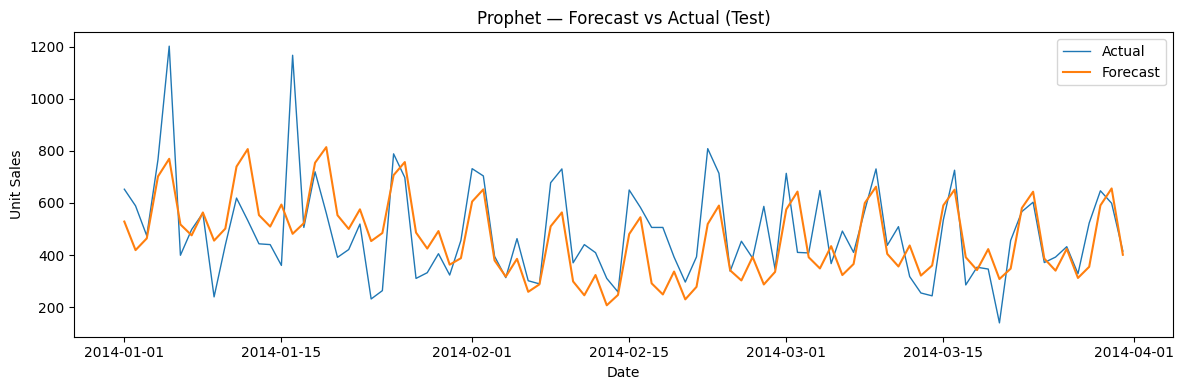

In [65]:
# Prophet Model
# Same train/test split as all other models
# Train: 2013-01-02 → 2013-12-31
# Test:  2014-01-01 → 2014-03-31

# Prophet requires specific column names: ds and y
train_prophet = y_train_ml.reset_index()
train_prophet.columns = ["ds", "y"]

test_prophet = y_test_ml.reset_index()
test_prophet.columns = ["ds", "y"]

# Fit Prophet on training data only
model_prophet = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="additive"
)

model_prophet.fit(train_prophet)

# Forecast over test period
future_prophet = model_prophet.make_future_dataframe(
    periods=len(y_test_ml),
    freq="D"
)

forecast_prophet = model_prophet.predict(future_prophet)

# Extract only test period predictions
y_pred_prophet = forecast_prophet.set_index("ds")["yhat"]
y_pred_prophet = y_pred_prophet.loc[y_test_ml.index]
y_pred_prophet = pd.Series(y_pred_prophet.values, index=y_test_ml.index)

# Clip negative predictions
y_pred_prophet = y_pred_prophet.clip(lower=0)

# Evaluate
prophet_metrics = evaluate_model(
    y_true=y_test_ml,
    y_pred=y_pred_prophet,
    model_name="Prophet (basic),",
    family="Statistical"
)

# Store the results
results.append(prophet_metrics)

plot_test_view(y_test_ml, y_pred_prophet, "Prophet — Forecast vs Actual (Test)")

**Note**: Prophet is evaluated using the same train/test split as all other models, train: 2013, test: Q1 2014.

Prophet achieves MAE: 109.95, RMSE: 152.26, sMAPE: 23.45%, the weakest performance among the candidate models evaluated so far.

With only one year of training data and a dominant weekly seasonality already captured by explicit lag and calendar features, Prophet's automatic decomposition approach does not provide a competitive advantage in this setting.

Prophet is therefore excluded from the final candidate shortlist and will not be logged to MLflow.

### 6.3 Deep Learning Models

#### LSTM

In [66]:
# LSTM

#The LSTM model is computationally intensive and may be slow to train on hardware without GPU support. 
'''
# Prepare series
train_series = y_train_ml.copy()
test_series  = y_test_ml.copy()

lookback = 28

# Scale using TRAIN ONLY
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1)).flatten()
test_scaled  = scaler.transform(test_series.values.reshape(-1, 1)).flatten()

def make_sequences(values_1d, lookback):
    """
    Convert a 1D array into supervised sequences:
    X shape: (samples, lookback, 1)
    y shape: (samples,)
    """
    X, y = [], []
    for i in range(lookback, len(values_1d)):
        X.append(values_1d[i - lookback:i])
        y.append(values_1d[i])
    X = np.array(X).reshape(-1, lookback, 1)
    y = np.array(y)
    return X, y


# Train sequences
X_train_seq, y_train_seq = make_sequences(train_scaled, lookback)

# Build model
model = Sequential([
    Input(shape=(lookback, 1)),
    LSTM(64, return_sequences=False),
    Dropout(0.1),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

# Fit with early stopping
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,   # validation is taken only from Train portion
    epochs=200,
    batch_size=16,
    callbacks=[es],
    verbose=0
)

# Rolling forecast on test one-step ahead
# I use the last lookback points from train + progressively from test
full_scaled = np.concatenate([train_scaled, test_scaled])

# Indices in the concatenated array corresponding to test start
test_start_idx = len(train_scaled)

preds_scaled = []

for t in range(test_start_idx, test_start_idx + len(test_scaled)):
    x_input = full_scaled[t - lookback:t].reshape(1, lookback, 1)
    y_hat = model.predict(x_input, verbose=0)[0, 0]
    preds_scaled.append(y_hat)

#Inverse scale back
preds = scaler.inverse_transform(np.array(preds_scaled).reshape(-1, 1)).flatten()
lstm_forecast = pd.Series(preds, index=test_series.index, name="LSTM (baseline)")


# Evaluate
lstm_metrics = evaluate_model(
    y_true=y_test_ml,
    y_pred=lstm_forecast,
    model_name="LSTM (baseline, lookback=28)",
    family="DL"
)
# Store the results
results.append(lstm_metrics)

# Plot test period
plot_test_view(y_test_ml, lstm_forecast, "LSTM — Forecast vs Actual (Test)") '''

'\n# Prepare series\ntrain_series = y_train_ml.copy()\ntest_series  = y_test_ml.copy()\n\nlookback = 28\n\n# Scale using TRAIN ONLY\nscaler = MinMaxScaler()\ntrain_scaled = scaler.fit_transform(train_series.values.reshape(-1, 1)).flatten()\ntest_scaled  = scaler.transform(test_series.values.reshape(-1, 1)).flatten()\n\ndef make_sequences(values_1d, lookback):\n    """\n    Convert a 1D array into supervised sequences:\n    X shape: (samples, lookback, 1)\n    y shape: (samples,)\n    """\n    X, y = [], []\n    for i in range(lookback, len(values_1d)):\n        X.append(values_1d[i - lookback:i])\n        y.append(values_1d[i])\n    X = np.array(X).reshape(-1, lookback, 1)\n    y = np.array(y)\n    return X, y\n\n\n# Train sequences\nX_train_seq, y_train_seq = make_sequences(train_scaled, lookback)\n\n# Build model\nmodel = Sequential([\n    Input(shape=(lookback, 1)),\n    LSTM(64, return_sequences=False),\n    Dropout(0.1),\n    Dense(1)\n])\n\nmodel.compile(optimizer="adam", loss="m

In [67]:
# ============================================================
# LSTM - Commented out for performance reasons
# Results: MAE ≈ 108.27 (underperforms vs tree-based models)
results.append({
    "Model": "LSTM (baseline, lookback=28)",
    "MAE": 108.01,
    "RMSE": 161.40,
    "sMAPE (%)": 22.33,
    "Family": "DL"
})

**Note**:  
Even with an extended lookback window (28 days), the LSTM model underperforms compared to tree-based feature-engineered models (MAE ≈ 108.27).

Given the limited training horizon and the strong, regular weekly seasonality, explicit lag and rolling features appear more effective than sequence-based deep learning in this setting.

This result highlights that model complexity should be aligned with dataset size and structural characteristics.

### 6.4 ML Results

In [68]:
# Model Comparison Table
results_df = pd.DataFrame(results)

# Sort by primary metric (MAE)
results_df = results_df.sort_values("MAE").reset_index(drop=True)

results_df

,Model,MAE,RMSE,sMAPE (%),Family
0,XGBoost (HyperOpt tuned),95.26,140.39,19.95,ML
1,XGBoost (lags + cyclical),95.52,140.94,20.04,ML
2,Random Forest (tuned),96.70,141.77,20.15,ML
3,Random Forest,97.42,140.80,20.33,ML
4,Linear Regression,102.58,151.33,21.36,ML
5,"LSTM (baseline, lookback=28)",108.01,161.40,22.33,DL
6,"Prophet (basic),",109.95,152.26,23.45,Statistical


#### Plot the Results table

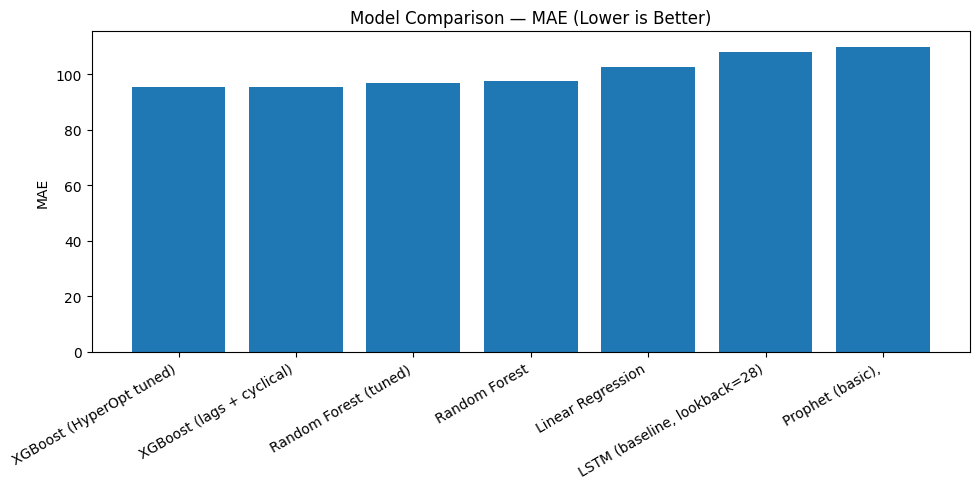

In [69]:
# Plot the results
plt.figure(figsize=(10,5))

plt.bar(results_df["Model"], results_df["MAE"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("MAE")
plt.title("Model Comparison — MAE (Lower is Better)")

plt.tight_layout()
plt.show()

**Note**: The table above summarizes the out-of-sample performance of all models evaluated on the fixed test period (January–March 2014).

Key observations:

- **XGBoost (HyperOpt tuned)** achieves the lowest MAE (95.26), confirming it as the champion model. The optimal configuration converges to shallow trees (max_depth=2, n_estimators=50), consistent with the limited training horizon.
- **Random Forest (tuned)** also benefits from a shallow configuration, improving over the baseline but remaining slightly behind XGBoost.
- **Linear Regression** provides a competitive baseline, confirming that the engineered features already carry substantial predictive signal.
- **LSTM** underperforms relative to tree-based models — with only one year of data and regular weekly seasonality, explicit feature engineering proves more effective than deep learning.
- **Prophet** is the weakest performer — automatic decomposition does not provide a competitive advantage when calendar features are already explicitly encoded.

Overall, shallow tree-based models with explicit feature engineering demonstrate the most robust predictive performance in this setting.

### 6.5 Experiment Tracking (MLflow)

#### Log Random Forest Tuned

In [70]:
# Log Random Forest tuned
with mlflow.start_run(run_name="RandomForest_tuned"):
    # Tags = metadata for filtering runs later in MLflow UI
    mlflow.set_tag("model_family", "machine_learning")
    mlflow.set_tag("notebook", "03")
    mlflow.set_tag("tuning_method", "grid_search")
    mlflow.set_tag("split", "train_2013_test_2014Q1")
    mlflow.set_tag("features_fixed", "yes")
    
    # Params = model configuration
    mlflow.log_params(grid_search.best_params_)
    
    # Metrics = performance on the fixed test set (Jan–Mar 2014)
    mlflow.log_metric("MAE",   round(float(rf_tuned_metrics["MAE"]), 2))
    mlflow.log_metric("RMSE",  round(float(rf_tuned_metrics["RMSE"]), 2))
    mlflow.log_metric("sMAPE", round(float(rf_tuned_metrics["sMAPE (%)"]), 2))

    # Log the trained model as an artifact
    mlflow.sklearn.log_model(best_rf, name="rf_tuned_model")
    # Log plot
    log_forecast_plot(y_test_ml, rf_tuned_forecast, "RandomForest_tuned")
    
print("Random Forest tuned logged to MLflow.")

2026/03/01 16:06:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged artifact: plots/randomforest_tuned_forecast.png
Random Forest tuned logged to MLflow.


#### Log XGBoost

In [71]:
# Log baseline XGBoost to MLflow

# This run represents the best baseline ML candidate (manual hyperparameters).
import mlflow.xgboost

with mlflow.start_run(run_name="XGBoost_FE_baseline"):
    # Tags = metadata for filtering runs later in MLflow UI
    mlflow.set_tag("model_family", "machine_learning")
    mlflow.set_tag("notebook", "03")
    mlflow.set_tag("tuning_method", "manual")
    mlflow.set_tag("split", "train_2013_test_2014Q1")
    mlflow.set_tag("random_state", "3")
    mlflow.set_tag("features_fixed", "yes")

    # Params = model configuration
    mlflow.log_param("model_type", "XGBRegressor")
    mlflow.log_param("n_estimators", xgb_model.n_estimators)
    mlflow.log_param("learning_rate", xgb_model.learning_rate)
    mlflow.log_param("max_depth", xgb_model.max_depth)
    mlflow.log_param("min_child_weight", xgb_model.min_child_weight)
    mlflow.log_param("colsample_bytree", xgb_model.colsample_bytree)

    # Unified feature list across all models 
    mlflow.log_param("n_features", len(features))
    mlflow.log_param("features", ",".join(features))

    # Metrics = performance on the fixed test set (Jan–Mar 2014)
    mlflow.log_metric("MAE", round(float(xgboost_metrics["MAE"]),2))
    mlflow.log_metric("RMSE", round(float(xgboost_metrics["RMSE"]),2))
    mlflow.log_metric("sMAPE", round(float(xgboost_metrics["sMAPE (%)"]),2))
  
    # Log the trained model as an artifact
    mlflow.xgboost.log_model(xgb_model, name="XGBoost")

    # Log plot
    log_forecast_plot(y_test_ml, xgb_forecast, "XGBoost_baseline")

print("XGboost baseline logged to MLflow.")

Logged artifact: plots/xgboost_baseline_forecast.png
XGboost baseline logged to MLflow.


#### Log XGBoost HyperOpt

In [72]:
# Log tuned XGBoost (HyperOpt) to MLflow
with mlflow.start_run(run_name="03_XGBoost_FE_HyperOpt"):
    
    # Tags = metadata for filtering runs later in MLflow UI
    mlflow.set_tag("model_family", "machine_learning")
    mlflow.set_tag("notebook", "03")
    mlflow.set_tag("tuning_method", "HyperOpt")
    mlflow.set_tag("split", "train_2013_test_2014Q1")
    mlflow.set_tag("random_state", "3")
    mlflow.set_tag("features_fixed", "yes")

    # Rounded tuned parameters for readability in MLflow UI
    mlflow.log_param("max_depth", best_params["max_depth"])
    mlflow.log_param("n_estimators", best_params["n_estimators"])
    mlflow.log_param("min_child_weight", best_params["min_child_weight"])
    mlflow.log_param("learning_rate", round(best_params["learning_rate"], 2))
    mlflow.log_param("subsample", round(best_params["subsample"], 2))
    mlflow.log_param("colsample_bytree", round(best_params["colsample_bytree"], 2))

    mlflow.log_param("model_type", "XGBRegressor")
    mlflow.log_param("n_features", len(features))
    mlflow.log_param("features", ",".join(features))

    mlflow.log_metric("MAE", round(float(xgb_tuned_metrics["MAE"]),2))
    mlflow.log_metric("RMSE", round(float(xgb_tuned_metrics["RMSE"]),2))
    mlflow.log_metric("sMAPE", round(float(xgb_tuned_metrics["sMAPE (%)"]),2))

    mlflow.xgboost.log_model(best_xgb, name="XGBoost")
    # Log Plot XGBoost HyperOpt
    log_forecast_plot(y_test_ml, xgb_tuned_forecast, "XGBoost_HyperOpt")
print("HyperOpt model logged.")

Logged artifact: plots/xgboost_hyperopt_forecast.png
HyperOpt model logged.


**Note**: XGBoost (HyperOpt tuned) achieves the lowest MAE (95.26) on the fixed test set, marginally improving over the baseline configuration (MAE: 95.52). The tuned model is therefore selected as the champion model and saved for deployment in the Streamlit app.

## 7. Full Model Comparison

In [73]:
# Convert results list to DataFrame first
results_df = pd.DataFrame(results)

# Load statistical results from notebook 02
results_stat = pd.read_csv(DATA_PATH / "results_statistical.csv")

final_comparison = pd.concat(
    [results_stat, results_df],
    ignore_index=True
).sort_values("MAE").reset_index(drop=True)

display(final_comparison)

,Model,MAE,RMSE,sMAPE (%),Family
0,XGBoost (HyperOpt tuned),95.260000,140.390000,19.950000,ML
1,XGBoost (lags + cyclical),95.520000,140.940000,20.040000,ML
2,"SARIMAX(1, 0, 1)x(0, 1, 1, 7) + calendar",96.662971,143.014644,20.383486,Statistical
3,Random Forest (tuned),96.700000,141.770000,20.150000,ML
4,Random Forest,97.420000,140.800000,20.330000,ML
5,"Holt-Winters (Additive, m=7)",97.444854,143.857167,20.570011,Statistical
6,"SARIMA(1,0,1)×(0,1,1,7)",97.797957,145.229614,20.601163,Statistical
7,Linear Regression,102.580000,151.330000,21.360000,ML
8,"LSTM (baseline, lookback=28)",108.010000,161.400000,22.330000,DL
9,"Prophet (basic),",109.950000,152.260000,23.450000,Statistical


**Comparison with Statistical Benchmark**

In Notebook 02, the best-performing statistical model (SARIMAX) achieved a MAE of approximately **96.66**.

The best ML model in this notebook (XGBoost) achieves a slightly lower MAE (≈ **95.52**), indicating a modest but consistent improvement over the statistical benchmark.

This suggests that explicit feature engineering combined with nonlinear tree-based models can capture incremental structure beyond classical seasonal modeling.

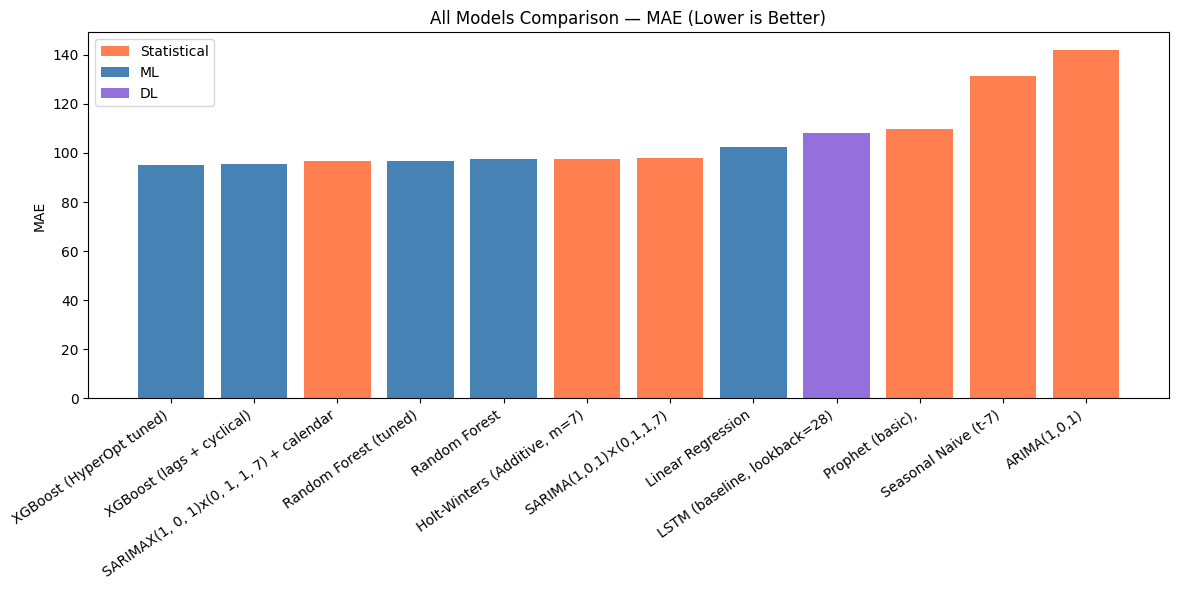

In [74]:
# Bar chart with color by family
colors = final_comparison["Family"].map({
    "Statistical": "coral",
    "ML": "steelblue",
    "DL": "mediumpurple",
})

plt.figure(figsize=(12, 6))
plt.bar(final_comparison["Model"], final_comparison["MAE"], color=colors)
plt.xticks(rotation=35, ha="right")
plt.ylabel("MAE")
plt.title("All Models Comparison — MAE (Lower is Better)")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="coral",       label="Statistical"),
    Patch(facecolor="steelblue",   label="ML"),
    Patch(facecolor="mediumpurple",label="DL"),
]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

## 8. Champion Model Selection - MLflow-based

This section:
1. Retrieves all relevant MLflow runs for this experiment
2. Filters only comparable candidate models
3. Selects the model with the lowest MAE (primary metric)
4. Prints a clean summary of the selected champion

### 8.1 Connect to MLflow for the best Model

In [75]:
# Connect to MLflow tracking store
client = MlflowClient()

experiment = client.get_experiment_by_name("Favorita_Sales_Forecasting")
experiment_id = experiment.experiment_id

runs = client.search_runs(experiment_ids=[experiment_id])

# Collect only comparable candidate runs
# Filter by:
# - fixed train/test split
# - fixed feature set
# - availability of MAE metric
data = []

for run in runs:
    tags = run.data.tags
    metrics = run.data.metrics
    params = run.data.params

    if tags.get("split") != "train_2013_test_2014Q1":
        continue

    if tags.get("features_fixed") != "yes":
        continue

    if "MAE" not in metrics:
        continue

    data.append({
        "run_id": run.info.run_id,
        "run_name": tags.get("mlflow.runName"),
        "tuning_method": tags.get("tuning_method"),
        "MAE": metrics.get("MAE"),
        "RMSE": metrics.get("RMSE"),
        "sMAPE": metrics.get("sMAPE"),
    })

df_candidates = pd.DataFrame(data).sort_values("MAE").reset_index(drop=True)

print("Candidate Models (sorted by MAE):")
display(df_candidates)

# Select Champion (lowest MAE)
champion = df_candidates.iloc[0]

print("\n🏆 Champion Model Selected:")
print(f"Run name      : {champion['run_name']}")
print(f"Tuning method : {champion['tuning_method']}")
print(f"MAE           : {champion['MAE']}")
print(f"RMSE          : {champion['RMSE']}")
print(f"sMAPE         : {champion['sMAPE']}")

Candidate Models (sorted by MAE):


,run_id,run_name,tuning_method,MAE,RMSE,sMAPE
0,14ee376651fc4853b767231689971c21,03_XGBoost_FE_HyperOpt,HyperOpt,95.26,140.39,19.95
1,883052686e114863942693aef599b00c,XGBoost_FE_baseline,manual,95.52,140.94,20.04
2,f01980e69d4b4cbfa6923670fcb9e399,SARIMAX_101_0117_calendar,manual,96.66,143.01,20.38
3,63c8e946eb0041399c7d9531f9d3331a,RandomForest_tuned,grid_search,96.70,141.77,20.15
4,ad0d7d91998a420cb1fbfd11b1012a49,02_HoltWinters_additive,optimized,97.44,143.86,20.57
5,84313b08b51f4fdfb9662371dfc70e2e,02_SARIMA_101_0117,manual,97.80,145.23,20.60



🏆 Champion Model Selected:
Run name      : 03_XGBoost_FE_HyperOpt
Tuning method : HyperOpt
MAE           : 95.26
RMSE          : 140.39
sMAPE         : 19.95


### 8.2 Tag Champion Model to MLflow

In [76]:
# Tag the champion run inside MLflow
client.set_tag(champion["run_id"], "selected_candidate", "yes")

In [77]:
# champion sXGBoost
run_id = champion["run_id"]

model_uri_candidates = [
    f"runs:/{run_id}/XGBoost",
    f"runs:/{run_id}/XGBoost",
]

loaded_model = None
for uri in model_uri_candidates:
    try:
        loaded_model = mlflow.xgboost.load_model(uri)
        print("Loaded model from:", uri)
        break
    except Exception:
        pass

if loaded_model is None:
    raise ValueError("Could not load the champion model from MLflow artifacts. Check artifact names in MLflow.")


Loaded model from: runs:/14ee376651fc4853b767231689971c21/XGBoost


### 8.3 Champion Model Residual Analysis

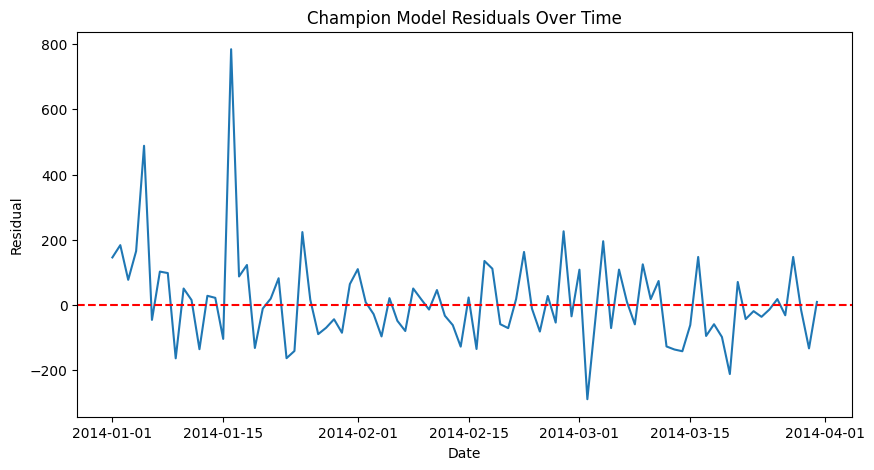

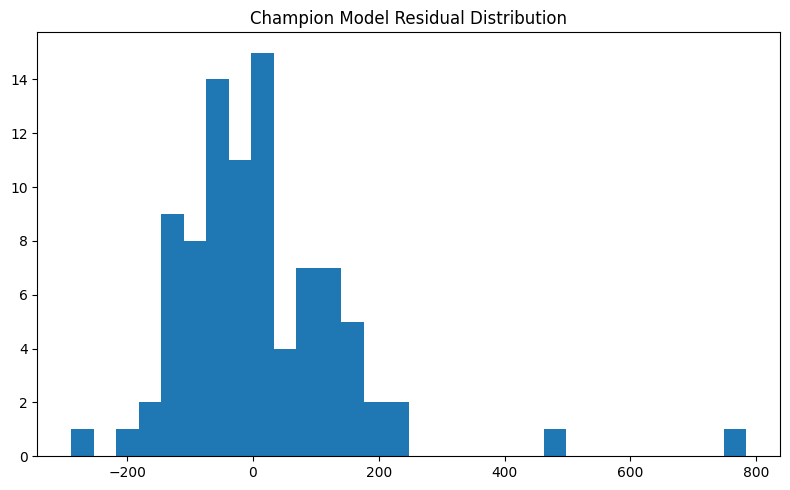

Residual mean: 10.49180433485243
Residual std: 140.78169210128817


In [78]:
# Champion Residual Analysis

# Predictions
y_pred = loaded_model.predict(X_test_ml)

# Residuals
residuals = y_test_ml - y_pred

# Residual plot
plt.figure(figsize=(10,5))
plt.plot(y_test_ml.index, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("Champion Model Residuals Over Time")
plt.show()

# Residual distribution
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30)
plt.title("Champion Model Residual Distribution")
plt.tight_layout()
plt.show()

# Residual statistics
print("Residual mean:", residuals.mean())
print("Residual std:", residuals.std())

**Note**: The residuals are broadly centered around zero, with no indication of systematic bias: the model does not consistently over‑ or under‑predict sales. 

Two noticeable positive spikes appear in early January 2014. The first, on 2014‑01‑05, is not linked to any holiday or known event and likely reflects a short‑term fluctuation in demand that the available features cannot capture.  
The second spike, around 2014‑01‑16, is also unrelated to calendar effects and represents another unexplained deviation. These isolated peaks suggest that some occasional demand changes remain outside the model’s ability to represent. 

From February onward, the residuals show much lower variance and no recurring patterns, indicating that the model behaves more consistently and generalizes well across the rest of the test period.

### 8.4 Champion Model Feature Importance

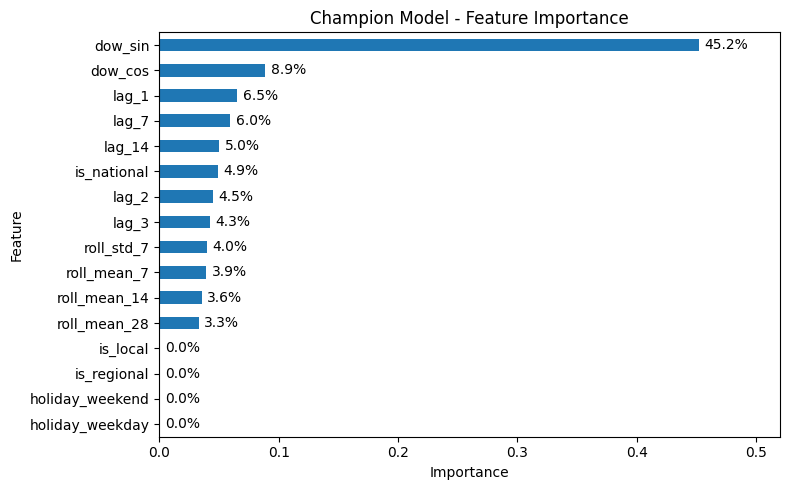

dow_sin            0.452108
dow_cos            0.088818
lag_1              0.065398
lag_7              0.059540
lag_14             0.050111
is_national        0.049054
lag_2              0.044752
lag_3              0.042654
roll_std_7         0.039647
roll_mean_7        0.039360
roll_mean_14       0.035628
roll_mean_28       0.032931
holiday_weekday    0.000000
holiday_weekend    0.000000
is_regional        0.000000
is_local           0.000000
dtype: float32

In [79]:
# Feature importance - Champion Model
imp = pd.Series(
    loaded_model.feature_importances_,
    index=X_train_ml.columns
).sort_values()

plt.figure(figsize=(8,5))
ax = imp.plot(kind="barh")

# Convert to percentage
imp_pct = imp / imp.sum() * 100

# Add percentage labels
for i, v in enumerate(imp):
    ax.text(
        v + imp.max()*0.01,   # small offset
        i,
        f"{imp_pct.iloc[i]:.1f}%",
        va="center"
    )

# Add padding on the right
ax.set_xlim(0, imp.max()*1.15)

plt.title("Champion Model - Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# Table
feat_imp = pd.Series(
    loaded_model.feature_importances_,
    index=X_train_ml.columns
).sort_values(ascending=False)

display(feat_imp)

**Note**: The feature importance analysis reveals that the model relies primarily on cyclical weekly seasonality and recent past sales to generate predictions.

The most important feature is `dow_sin`, followed by `dow_cos`, which together encode the cyclical structure of the weekly calendar. This confirms that weekly seasonality is the dominant driver of sales variability, consistent with the patterns observed during the exploratory data analysis.

Lag features (`lag_1`, `lag_2`, `lag_3`, `lag_7`, `lag_14`) also contribute meaningfully to the model. These features allow the model to capture short-term persistence and weekly recurrence effects, reflecting the autoregressive structure of the time series.

Rolling statistics (`roll_mean_*`, `roll_std_7`) provide additional contextual information about the local level and variability of the series, helping stabilize predictions.

In contrast, holiday-related features (`holiday_weekday`, `holiday_weekend`, `is_regional`, `is_local`) show zero importance. This indicates that, in this aggregated dataset, holidays do not provide consistent predictive signal beyond what is already captured by weekly seasonality and autoregressive patterns.

This result is fully consistent with the exploratory analysis, which showed that holiday effects are heterogeneous and do not produce a stable or systematic impact on sales.

Overall, the model behaves as expected: it relies on stable temporal structure rather than external calendar indicators that lack consistent predictive value in this simplified setting.

### 8.5 Save the model

In [ ]:
# Save the champion model to corporacion_favorita root
out_path = MODEL_PATH / "champion_model.pkl"
joblib.dump(best_xgb, out_path)
print("Champion model saved to:", out_path)